In [1]:
import matplotlib.pyplot as plt
from pathlib import Path

# Folder to store all figures
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

# Counter for filenames
_plot_counter = {"count": 0}

# Store original show()
_original_show = plt.show

def auto_save_show(*args, **kwargs):
    _plot_counter["count"] += 1
    filename = FIG_DIR / f"figure_{_plot_counter['count']:02d}.pdf"
    
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    print(f"Saved: {filename}")
    
    return _original_show(*args, **kwargs)

# 🔥 Override plt.show globally
plt.show = auto_save_show

In [2]:
import requests
import pandas as pd
from rdkit import Chem
from rdkit.Chem import PandasTools
from rdkit.Chem.FilterCatalog import FilterCatalog, FilterCatalogParams

# ================================
# STEP 1 — Download EAAT2 data
# ================================

TARGET_CHEMBL_ID = "CHEMBL4973"

print("Downloading EAAT2 activity data from ChEMBL...")

url = f"https://www.ebi.ac.uk/chembl/api/data/activity.json?target_chembl_id={TARGET_CHEMBL_ID}&standard_type=IC50&limit=1000"

all_rows = []

while url:
    r = requests.get(url)
    data = r.json()

    for act in data["activities"]:
        if act.get("canonical_smiles") and act.get("standard_value"):
            all_rows.append({
                "smiles": act["canonical_smiles"],
                "ic50_nM": act["standard_value"]
            })

    url = data["page_meta"]["next"]

df = pd.DataFrame(all_rows)

print("Raw dataset size:", len(df))

# ================================
# STEP 2 — Clean IC50 values
# ================================

df["ic50_nM"] = pd.to_numeric(df["ic50_nM"], errors="coerce")
df = df.dropna()
df = df.drop_duplicates(subset="smiles")

print("After cleaning:", len(df))

# ================================
# STEP 3 — Convert to RDKit molecules
# ================================

print("Generating RDKit molecules...")

df["mol"] = df["smiles"].apply(Chem.MolFromSmiles)
df = df[df["mol"].notna()].reset_index(drop=True)

print("Valid molecules:", len(df))

# ================================
# STEP 4 — Apply PAINS filters
# ================================

print("Applying PAINS filters...")

params = FilterCatalogParams()
params.AddCatalog(FilterCatalogParams.FilterCatalogs.PAINS)

catalog = FilterCatalog(params)

def is_pains(mol):
    return catalog.HasMatch(mol)

df["is_pains"] = df["mol"].apply(is_pains)

print("PAINS compounds found:", df["is_pains"].sum())

# ================================
# STEP 5 — Remove PAINS compounds
# ================================

df_clean = df[~df["is_pains"]].reset_index(drop=True)
from rdkit.Chem import Descriptors

print("Applying Lipinski filtering...")

def calculate_lipinski(mol):
    mw = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    hbd = Descriptors.NumHDonors(mol)
    hba = Descriptors.NumHAcceptors(mol)

    violations = 0
    if mw > 500: violations += 1
    if logp > 5: violations += 1
    if hbd > 5: violations += 1
    if hba > 10: violations += 1

    return pd.Series([mw, logp, hbd, hba, violations])

df_clean[["MW", "LogP", "HBD", "HBA", "Lipinski_violations"]] = \
    df_clean["mol"].apply(calculate_lipinski)

print("Compounds with >1 violation:",
      (df_clean["Lipinski_violations"] > 1).sum())

# Keep compounds with 0 or 1 violation
df_druglike = df_clean[df_clean["Lipinski_violations"] <= 1].reset_index(drop=True)

print("Final drug-like dataset size:", len(df_druglike))

print("Final clean dataset size:", len(df_clean))
##################################################################CNS filltering
print("Applying CNS-specific filtering...")

def calculate_cns(mol):
    mw = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    hbd = Descriptors.NumHDonors(mol)
    hba = Descriptors.NumHAcceptors(mol)
    tpsa = Descriptors.TPSA(mol)
    rot = Descriptors.NumRotatableBonds(mol)

    violations = 0
    if mw > 450: violations += 1
    if not (2 <= logp <= 4): violations += 1
    if hbd > 3: violations += 1
    if hba > 7: violations += 1
    if tpsa > 90: violations += 1
    if rot > 8: violations += 1

    return pd.Series([tpsa, rot, violations])

df_druglike[["TPSA", "RotBonds", "CNS_violations"]] = \
    df_druglike["mol"].apply(calculate_cns)

print("Compounds failing CNS criteria:",
      (df_druglike["CNS_violations"] > 1).sum())

# Keep compounds with 0 or 1 CNS violation
df_cns = df_druglike[df_druglike["CNS_violations"] <= 1].reset_index(drop=True)

print("Final CNS-optimized dataset size:", len(df_cns))

# ================================
# STEP 6 — Save cleaned dataset
# ================================

df_cns.drop(columns=["mol", "is_pains"]).to_csv(
    "test_plus_lipenski_CNS.csv",
    index=False
)
print("Final dataset saved as test_plus_lipenski_CNS.csv")



Raw dataset size: 364
After cleaning: 231
Generating RDKit molecules...
Valid molecules: 231
Applying PAINS filters...
PAINS compounds found: 14
Applying Lipinski filtering...
Compounds with >1 violation: 4
Final drug-like dataset size: 213
Final clean dataset size: 217
Applying CNS-specific filtering...
Compounds failing CNS criteria: 140
Final CNS-optimized dataset size: 73
Final dataset saved as test_plus_lipenski_CNS.csv


Plotting property distributions...
Saved: figures\figure_01.pdf


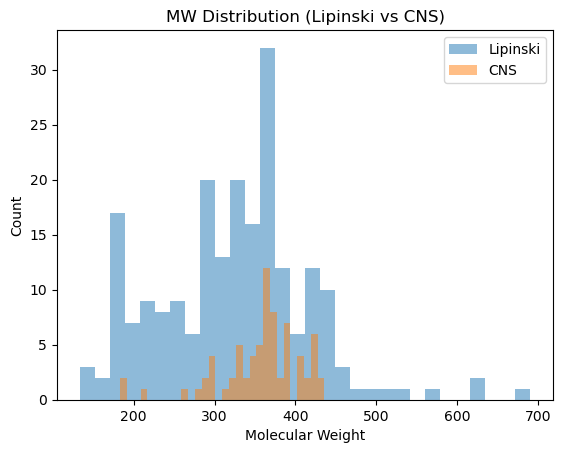

Saved: figures\figure_02.pdf


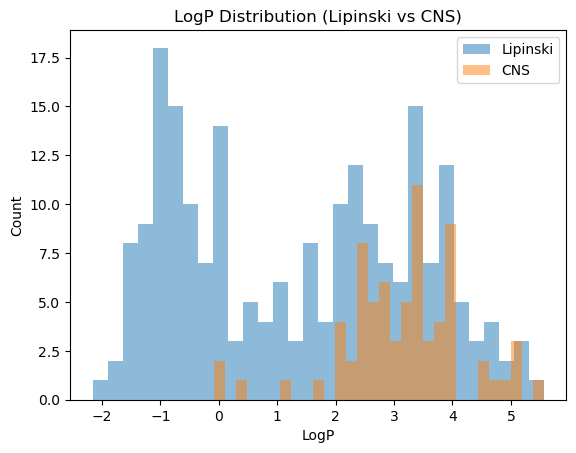

Saved: figures\figure_03.pdf


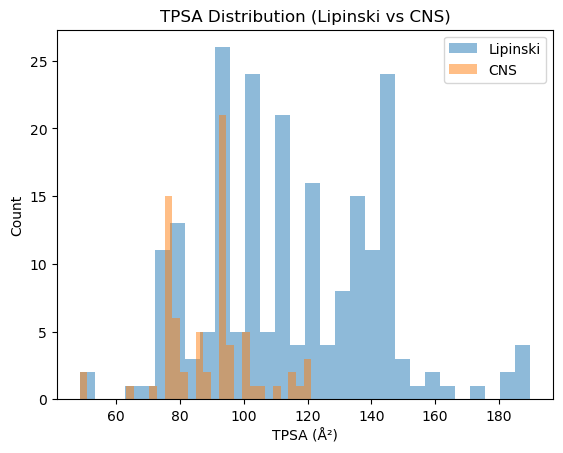

In [3]:
# ================================
# STEP 7 — Property Distributions
# ================================

import matplotlib.pyplot as plt

print("Plotting property distributions...")

# --- Molecular Weight ---
plt.figure()
plt.hist(df_druglike["MW"], bins=30, alpha=0.5)
plt.hist(df_cns["MW"], bins=30, alpha=0.5)
plt.xlabel("Molecular Weight")
plt.ylabel("Count")
plt.title("MW Distribution (Lipinski vs CNS)")
plt.legend(["Lipinski", "CNS"])
plt.show()


# --- LogP ---
plt.figure()
plt.hist(df_druglike["LogP"], bins=30, alpha=0.5)
plt.hist(df_cns["LogP"], bins=30, alpha=0.5)
plt.xlabel("LogP")
plt.ylabel("Count")
plt.title("LogP Distribution (Lipinski vs CNS)")
plt.legend(["Lipinski", "CNS"])
plt.show()


# --- TPSA ---
plt.figure()
plt.hist(df_druglike["TPSA"], bins=30, alpha=0.5)
plt.hist(df_cns["TPSA"], bins=30, alpha=0.5)
plt.xlabel("TPSA (Å²)")
plt.ylabel("Count")
plt.title("TPSA Distribution (Lipinski vs CNS)")
plt.legend(["Lipinski", "CNS"])
plt.show()

In [4]:
# ================================
# STEP 8 — ML Comparison
# ================================

import numpy as np
from rdkit.Chem import rdFingerprintGenerator
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

print("Training ML models (Lipinski vs CNS)...")

# Morgan fingerprint generator
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(
    radius=2,
    fpSize=1024
)

def featurize(df_input):
    X = np.array([
        np.array(morgan_gen.GetFingerprint(m))
        for m in df_input["mol"]
    ])
    
    # convert IC50 nM to pIC50
    y = -np.log10(df_input["ic50_nM"].astype(float) * 1e-9)
    
    return X, y


# -----------------------------
# Lipinski dataset
# -----------------------------
X_lip, y_lip = featurize(df_druglike)

X_train, X_test, y_train, y_test = train_test_split(
    X_lip, y_lip, test_size=0.2, random_state=42
)

model_lip = RandomForestRegressor(n_estimators=200, random_state=42)
model_lip.fit(X_train, y_train)

y_pred = model_lip.predict(X_test)

r2_lip = r2_score(y_test, y_pred)
rmse_lip = np.sqrt(mean_squared_error(y_test, y_pred))


# -----------------------------
# CNS dataset
# -----------------------------
X_cns, y_cns = featurize(df_cns)

X_train, X_test, y_train, y_test = train_test_split(
    X_cns, y_cns, test_size=0.2, random_state=42
)

model_cns = RandomForestRegressor(n_estimators=200, random_state=42)
model_cns.fit(X_train, y_train)

y_pred = model_cns.predict(X_test)

r2_cns = r2_score(y_test, y_pred)
rmse_cns = np.sqrt(mean_squared_error(y_test, y_pred))


# -----------------------------
# Results
# -----------------------------

print("\nModel Performance Comparison")
print("----------------------------")
print(f"Lipinski  R2:   {r2_lip:.3f}")
print(f"Lipinski  RMSE: {rmse_lip:.3f}")
print()
print(f"CNS       R2:   {r2_cns:.3f}")
print(f"CNS       RMSE: {rmse_cns:.3f}")

Training ML models (Lipinski vs CNS)...

Model Performance Comparison
----------------------------
Lipinski  R2:   0.630
Lipinski  RMSE: 0.809

CNS       R2:   0.928
CNS       RMSE: 0.400


In [5]:
# ================================
# STEP 9 — Scaffold Split (CNS dataset)
# ================================

from rdkit.Chem.Scaffolds import MurckoScaffold
from collections import defaultdict

print("\nRunning scaffold split validation...")

def generate_scaffold(mol):
    return MurckoScaffold.MurckoScaffoldSmiles(mol=mol)

# Add scaffold column
df_cns["scaffold"] = df_cns["mol"].apply(generate_scaffold)

# Group molecules by scaffold
scaffold_groups = defaultdict(list)

for idx, scaffold in enumerate(df_cns["scaffold"]):
    scaffold_groups[scaffold].append(idx)

# Sort scaffolds by size (largest first)
scaffold_sets = sorted(
    scaffold_groups.values(),
    key=lambda x: len(x),
    reverse=True
)

train_idx = []
test_idx = []

total_size = len(df_cns)
train_cutoff = int(0.8 * total_size)

for scaffold in scaffold_sets:
    if len(train_idx) + len(scaffold) <= train_cutoff:
        train_idx.extend(scaffold)
    else:
        test_idx.extend(scaffold)

# Featurize
X, y = featurize(df_cns)

X_train = X[train_idx]
y_train = y.iloc[train_idx]

X_test = X[test_idx]
y_test = y.iloc[test_idx]

# Train model
model_scaffold = RandomForestRegressor(n_estimators=200, random_state=42)
model_scaffold.fit(X_train, y_train)

y_pred = model_scaffold.predict(X_test)

r2_scaffold = r2_score(y_test, y_pred)
rmse_scaffold = np.sqrt(mean_squared_error(y_test, y_pred))

print("\nScaffold Split Performance")
print("--------------------------")
print(f"R2:   {r2_scaffold:.3f}")
print(f"RMSE: {rmse_scaffold:.3f}")


Running scaffold split validation...

Scaffold Split Performance
--------------------------
R2:   -0.139
RMSE: 1.374


In [6]:
# ================================
# STEP 10 — Scaffold Cross-Validation
# ================================

from sklearn.model_selection import GroupKFold

print("\nRunning 5-fold scaffold cross-validation...")

# Prepare features
X, y = featurize(df_cns)

# Generate scaffold groups
groups = df_cns["scaffold"]

gkf = GroupKFold(n_splits=5)

r2_scores = []
rmse_scores = []

for train_idx, test_idx in gkf.split(X, y, groups):
    
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    model = RandomForestRegressor(n_estimators=200, random_state=42)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    r2_scores.append(r2_score(y_test, y_pred))
    rmse_scores.append(np.sqrt(mean_squared_error(y_test, y_pred)))

print("\nScaffold Cross-Validation Results")
print("---------------------------------")
print(f"Mean R2:   {np.mean(r2_scores):.3f}")
print(f"Std R2:    {np.std(r2_scores):.3f}")
print(f"Mean RMSE: {np.mean(rmse_scores):.3f}")
print(f"Std RMSE:  {np.std(rmse_scores):.3f}")


Running 5-fold scaffold cross-validation...

Scaffold Cross-Validation Results
---------------------------------
Mean R2:   -0.043
Std R2:    1.316
Mean RMSE: 0.608
Std RMSE:  0.274


In [7]:
# ================================
# STEP 11 — Scaffold Statistics
# ================================

print("\nAnalyzing scaffold distribution...")

# Count unique scaffolds
unique_scaffolds = df_cns["scaffold"].nunique()
total_compounds = len(df_cns)

print(f"Total compounds (CNS set): {total_compounds}")
print(f"Unique scaffolds: {unique_scaffolds}")

# Count compounds per scaffold
scaffold_counts = df_cns["scaffold"].value_counts()

print("\nTop 10 largest scaffolds:")
print(scaffold_counts.head(10))


Analyzing scaffold distribution...
Total compounds (CNS set): 73
Unique scaffolds: 38

Top 10 largest scaffolds:
scaffold
c1ccc(-c2ccccc2)cc1                        14
O=C1CC(c2ccccc2)CC2=C1C(c1ccccc1)C=CO2      7
c1ccc2c(c1)Cc1ccccc1-2                      5
O=C1CN(Cc2ccccc2)CC2=C1C(c1ccccc1)C=CO2     5
O=C1NC(=O)C(=Cc2ccccc2)S1                   3
O=C1NC(=O)C(=Cc2ccc(-c3ccccc3)o2)S1         3
c1ccc(Oc2ccccc2)cc1                         2
O=C1CC(c2ccccc2)CC2=C1CC=CO2                2
O=C1CC(c2ccccc2)CC2=C1C(c1cccs1)C=CO2       2
O=C1CC(c2cc(=O)oc3ccccc23)CC2=C1CC=CO2      2
Name: count, dtype: int64


Saved: figures\figure_04.pdf


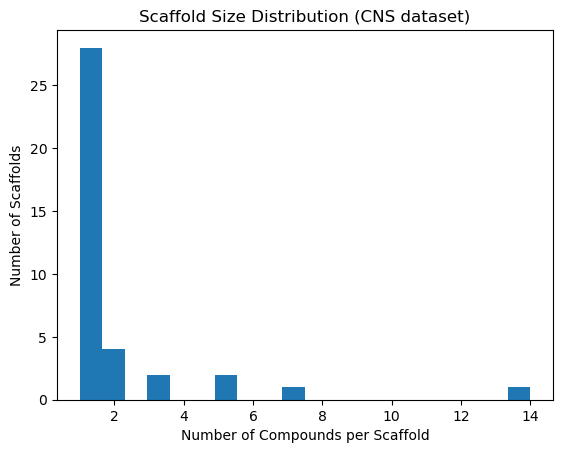

In [8]:
# ================================
# STEP 12 — Scaffold Size Distribution Plot
# ================================

import matplotlib.pyplot as plt

plt.figure()
plt.hist(scaffold_counts.values, bins=20)
plt.xlabel("Number of Compounds per Scaffold")
plt.ylabel("Number of Scaffolds")
plt.title("Scaffold Size Distribution (CNS dataset)")
plt.show()

In [9]:
# ================================
# STEP 13 — Dummy Baseline (Regression)
# ================================

from sklearn.dummy import DummyRegressor

print("\nRunning Dummy baseline model...")

X, y = featurize(df_cns)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train, y_train)

y_dummy = dummy.predict(X_test)

r2_dummy = r2_score(y_test, y_dummy)
rmse_dummy = np.sqrt(mean_squared_error(y_test, y_dummy))

print("\nDummy Model Performance")
print("----------------------")
print(f"R2:   {r2_dummy:.3f}")
print(f"RMSE: {rmse_dummy:.3f}")


Running Dummy baseline model...

Dummy Model Performance
----------------------
R2:   -0.082
RMSE: 1.556


In [10]:
# ================================
# STEP 14 — Hyperparameter Tuning
# ================================

from sklearn.model_selection import GridSearchCV

print("\nRunning GridSearchCV...")

param_grid = {
    "n_estimators": [100, 200, 500],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

rf = RandomForestRegressor(random_state=42)

grid = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X, y)

print("\nBest Parameters:", grid.best_params_)
print("Best CV R2:", grid.best_score_)


Running GridSearchCV...

Best Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 500}
Best CV R2: -0.27098624603717125


In [11]:
# ================================
# STEP 15 — Classification Setup
# ================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix

print("\nBuilding classification model...")

df_cns["pIC50"] = -np.log10(df_cns["ic50_nM"].astype(float) * 1e-9)
df_cns["active"] = df_cns["pIC50"] >= 6

X, y_class = featurize(df_cns)
y_class = df_cns["active"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y_class, test_size=0.2, random_state=42
)

clf = RandomForestClassifier(n_estimators=200, random_state=42)
clf.fit(X_train, y_train)

y_proba = clf.predict_proba(X_test)[:, 1]
y_pred = clf.predict(X_test)

roc_auc = roc_auc_score(y_test, y_proba)

print("\nClassification ROC-AUC:", round(roc_auc, 3))


Building classification model...

Classification ROC-AUC: 1.0


Saved: figures\figure_05.pdf


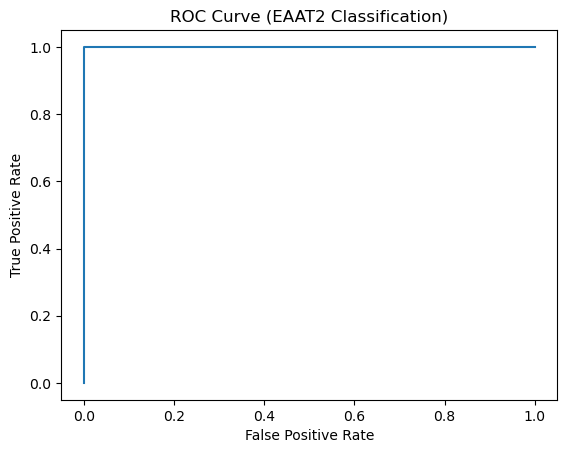

In [12]:
# ================================
# STEP 16 — ROC Curve Plot
# ================================

import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (EAAT2 Classification)")
plt.show()

Saved: figures\figure_06.pdf


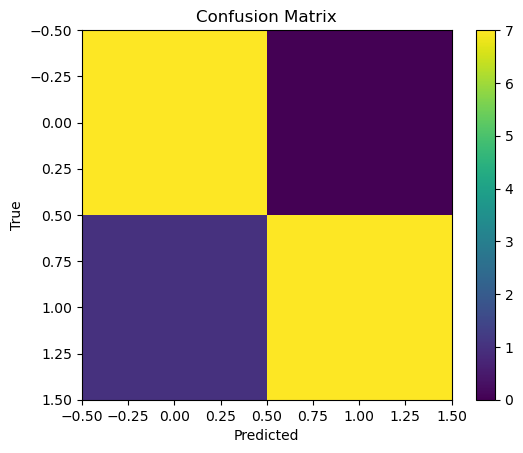

In [13]:
# ================================
# STEP 17 — Confusion Matrix
# ================================

cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.colorbar()
plt.show()


Generating learning curve...
Saved: figures\figure_07.pdf


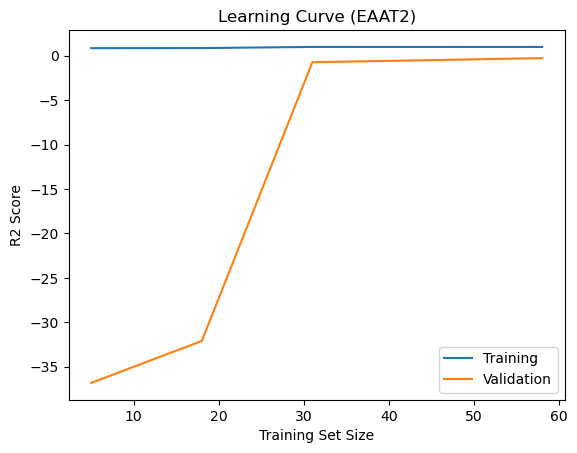

In [14]:
# ================================
# STEP 18 — Learning Curve
# ================================

from sklearn.model_selection import learning_curve

print("\nGenerating learning curve...")

train_sizes, train_scores, test_scores = learning_curve(
    RandomForestRegressor(n_estimators=200, random_state=42),
    X,
    y,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure()
plt.plot(train_sizes, train_mean)
plt.plot(train_sizes, test_mean)
plt.xlabel("Training Set Size")
plt.ylabel("R2 Score")
plt.title("Learning Curve (EAAT2)")
plt.legend(["Training", "Validation"])
plt.show()



Calculating feature importance...
Saved: figures\figure_08.pdf


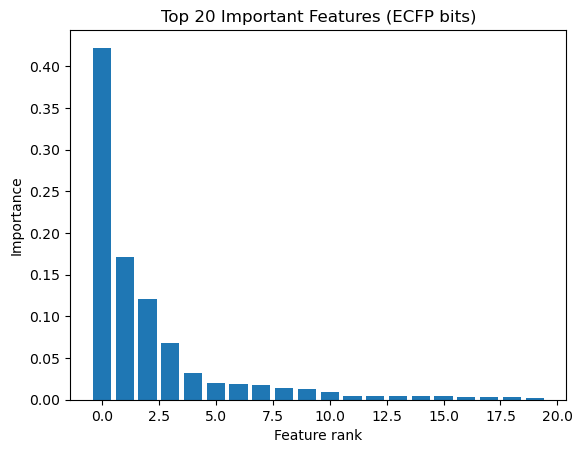

In [15]:
import matplotlib.pyplot as plt
import numpy as np

print("Calculating feature importance...")

importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

# Plot top 20 features
plt.figure()
plt.title("Top 20 Important Features (ECFP bits)")
plt.bar(range(20), importances[indices[:20]])
plt.xlabel("Feature rank")
plt.ylabel("Importance")
plt.show()

Running PCA...
Saved: figures\figure_09.pdf


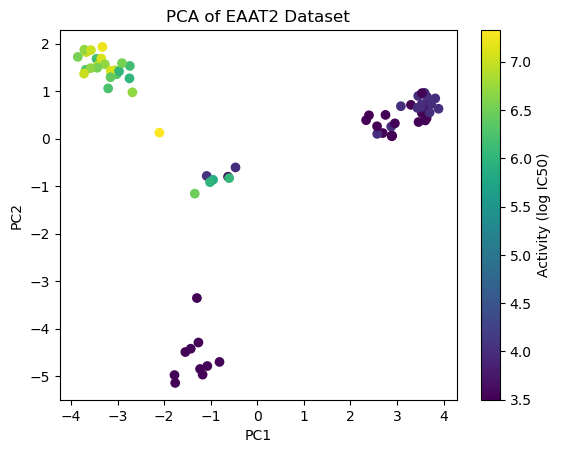

In [16]:
from sklearn.decomposition import PCA

print("Running PCA...")

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure()
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap="viridis")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of EAAT2 Dataset")
plt.colorbar(label="Activity (log IC50)")
plt.show()

Saved: figures\figure_10.pdf


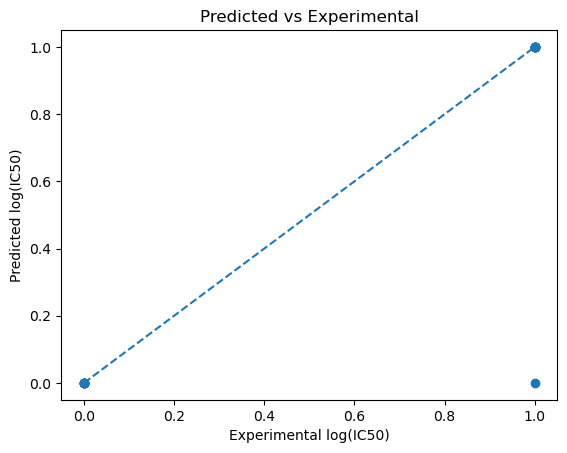

In [17]:
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Experimental log(IC50)")
plt.ylabel("Predicted log(IC50)")
plt.title("Predicted vs Experimental")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle="--")
plt.show()